In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
N = 3000
x1 = np.random.uniform(-2,2,N)
x2 = np.random.uniform(-2,2,N)
X = np.vstack([x1,x2]).T
y = ((x1**2 + x2**2) > 1.5).astype(int)
y = y.reshape(-1,1)
print(X.shape,y.shape)

(3000, 2) (3000, 1)


In [2]:
idx = np.random.permutation(N)
train_end = int(0.7*N)
val_end = int(0.85*N)
train_idx = idx[:train_end]
val_idx = idx[train_end:val_end]
test_idx = idx[val_end:]
X_train = X[train_idx]
y_train = y[train_idx]
X_val = X[val_idx]
y_val = y[val_idx]
X_test = X[test_idx]
y_test = y[test_idx]
print(X_train.shape, X_val.shape, X_test.shape)

(2100, 2) (450, 2) (450, 2)


In [3]:
def bce_loss(y,yp):
    eps = 1e-8
    yp = np.clip(yp,eps,1-eps)
    loss = -(y*np.log(yp) + (1-y)*np.log(1-yp))
    return np.mean(loss)

def accuracy(y,yp):
    yp_bin = (yp>=0.5).astype(int)
    return np.mean(yp_bin == y)

In [4]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s*(1-s)

def relu(z):
    return np.maximum(0,z)

def relu_deriv(z):
    return (z>0).astype(float)

In [5]:
def init_network(layers):
    params = {}
    for i in range(len(layers)-1):
        params["W"+str(i+1)] = np.random.randn(layers[i],layers[i+1]) * np.sqrt(2/layers[i])
        params["b"+str(i+1)] = np.zeros((1,layers[i+1]))
    return params

In [6]:
def forward(X,params,activation):
    cache = {}
    A = X
    L = len(params)//2
    for l in range(1,L):
        Z = A @ params["W"+str(l)] + params["b"+str(l)]
        if activation=="sigmoid":
            A = sigmoid(Z)
        else:
            A = relu(Z)
        cache["Z"+str(l)] = Z
        cache["A"+str(l)] = A
    Z = A @ params["W"+str(L)] + params["b"+str(L)]
    A = sigmoid(Z)
    cache["Z"+str(L)] = Z
    cache["A"+str(L)] = A
    return A,cache

In [7]:
def backward(X,y,params,cache,activation):
    grads = {}
    L = len(params)//2
    m = X.shape[0]
    A_final = cache["A"+str(L)]
    dZ = A_final - y

    for l in reversed(range(1,L+1)):
        A_prev = X if l==1 else cache["A"+str(l-1)]
        Z = cache["Z"+str(l)]
        if l==L:
            dZ = A_final - y
        else:
            if activation=="sigmoid":
                dZ = dA * sigmoid_deriv(cache["A"+str(l)])
            else:
                dZ = dA * relu_deriv(Z)
        grads["dW"+str(l)] = A_prev.T @ dZ / m
        grads["db"+str(l)] = np.sum(dZ, axis=0, keepdims=True) / m

        grads["dW"+str(l)] = np.clip(grads["dW"+str(l)], -5, 5)
        grads["db"+str(l)] = np.clip(grads["db"+str(l)], -5, 5)

        dA = dZ @ params["W"+str(l)].T

    return grads

In [8]:
def sgd_update(params,grads,lr):
    L = len(params)//2
    for l in range(1,L+1):
        params["W"+str(l)] -= lr*grads["dW"+str(l)]
        params["b"+str(l)] -= lr*grads["db"+str(l)]

In [9]:
def momentum_update(params,grads,vel,lr,beta=0.9):
    L = len(params)//2
    for l in range(1,L+1):
        vel["W"+str(l)] = beta*vel["W"+str(l)] + lr*grads["dW"+str(l)]
        vel["b"+str(l)] = beta*vel["b"+str(l)] + lr*grads["db"+str(l)]
        params["W"+str(l)] -= vel["W"+str(l)]
        params["b"+str(l)] -= vel["b"+str(l)]

In [10]:
def train_model(X_train,y_train,X_val,y_val,layer_sizes,activation,optimizer,epochs=200,lr=0.01):
    params = init_network(layer_sizes)
    vel={}
    for l in range(1,len(layer_sizes)):
        vel["W"+str(l)] = np.zeros_like(params["W"+str(l)])
        vel["b"+str(l)] = np.zeros_like(params["b"+str(l)])

    train_loss=[]
    val_loss=[]
    train_acc=[]
    val_acc=[]

    for e in range(epochs):
        yp,cache = forward(X_train,params,activation)
        loss = bce_loss(y_train,yp)
        acc = accuracy(y_train,yp)
        grads = backward(X_train,y_train,params,cache,activation)

        if optimizer=="sgd":
            sgd_update(params,grads,lr)
        else:
            momentum_update(params,grads,vel,lr)

        yp_val,_ = forward(X_val,params,activation)

        train_loss.append(loss)
        val_loss.append(bce_loss(y_val,yp_val))
        train_acc.append(acc)
        val_acc.append(accuracy(y_val,yp_val))

    return params,train_loss,val_loss,train_acc,val_acc

In [11]:
model_2 = [2,8,1]
model_5 = [2,8,8,8,8,1]
model_10 = [2,8,8,8,8,8,8,8,8,8,1]

In [12]:
params,tl,vl,ta,va = train_model(
    X_train,y_train,X_val,y_val,
    model_5,
    activation="relu",
    optimizer="momentum",
    epochs=200
)

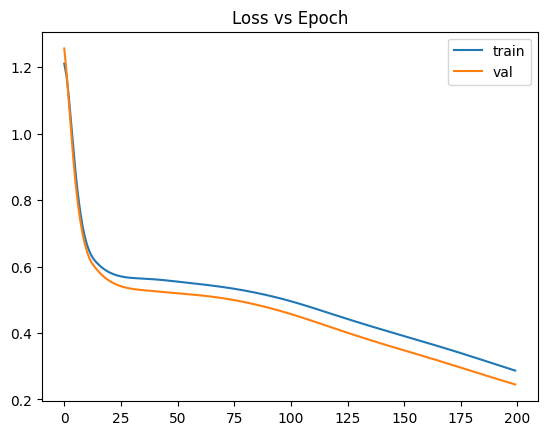

In [13]:
plt.plot(tl,label="train")
plt.plot(vl,label="val")
plt.legend()
plt.title("Loss vs Epoch")
plt.show()

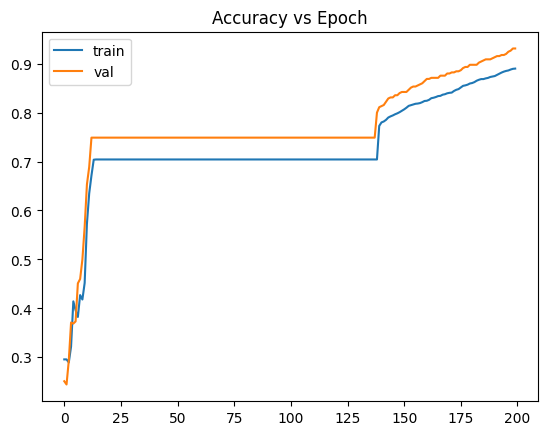

In [14]:
plt.plot(ta,label="train")
plt.plot(va,label="val")
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()

In [15]:
yp_test,_ = forward(X_test,params,"relu")

print("Test Loss:",bce_loss(y_test,yp_test))
print("Test Accuracy:",accuracy(y_test,yp_test))

Test Loss: 0.25841697932458985
Test Accuracy: 0.9133333333333333


## Analysis

Does increasing depth always improve validation performance?
No. Increasing depth can initially improve learning capacity, but deeper networks often suffer from vanishing gradients and overfitting, which may reduce validation performance.


What happens to test performance as depth increases?
Test accuracy may improve up to a certain depth but eventually declines due to overfitting and unstable gradient propagation.


Do sigmoid networks degrade faster with depth?
Yes. Sigmoid activations compress gradients into a small range (0,1), which causes gradients to shrink during backpropagation. This leads to vanishing gradient problems, especially in deeper networks.


Does optimizer choice affect deep networks more than shallow ones?
Yes. Optimizers like Momentum help propagate gradients more effectively in deep networks, improving convergence speed and stability compared to simple SGD.


Does validation performance predict test performance reliably?
Generally yes, because validation data is unseen during training. However, if excessive hyperparameter tuning is performed on the validation set, it may become biased.

In [16]:
def generate_images(N):
    images = []
    labels = []

    for i in range(N):
        img = np.zeros((8,8))
        if np.random.rand() < 0.5:
            img[:,4] = 1
            label = 0
        else:
            img[4,:] = 1
            label = 1

        img += np.random.normal(0,0.1,(8,8))
        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels).reshape(-1,1)

In [17]:
X_img, y_img = generate_images(3000)
print(X_img.shape, y_img.shape)

(3000, 8, 8) (3000, 1)


In [18]:
N = X_img.shape[0]
indices = np.random.permutation(N)
train_end = int(0.7*N)
val_end = int(0.85*N)
train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]
X_train_img = X_img[train_idx]
y_train_img = y_img[train_idx]
X_val_img = X_img[val_idx]
y_val_img = y_img[val_idx]
X_test_img = X_img[test_idx]
y_test_img = y_img[test_idx]

In [19]:
X_train_dense = X_train_img.reshape(-1,64)
X_val_dense = X_val_img.reshape(-1,64)
X_test_dense = X_test_img.reshape(-1,64)

In [20]:
dense_model = [64,32,1]

In [21]:
params_dense,train_loss_dense,val_loss_dense,train_acc_dense,val_acc_dense = train_model(
    X_train_dense,
    y_train_img,
    X_val_dense,
    y_val_img,
    dense_model,
    activation="relu",
    optimizer="momentum",
    epochs=200,
    lr = 0.001
)

In [22]:
test_pred_dense,_ = forward(X_test_dense,params_dense,"relu")
print("Dense Test Loss:",bce_loss(y_test_img,test_pred_dense))
print("Dense Test Accuracy:",accuracy(y_test_img,test_pred_dense))

Dense Test Loss: 0.07044000279518726
Dense Test Accuracy: 1.0


In [23]:
def conv2d(X,K):
    H,W = X.shape
    F = K.shape[0]
    out_h = H-F+1
    out_w = W-F+1
    output = np.zeros((out_h,out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = X[i:i+F, j:j+F]
            output[i,j] = np.sum(region*K)
    return output

In [24]:
def conv_layer(X,filters):
    outputs = []
    for f in filters:
        outputs.append(conv2d(X,f))
    return np.array(outputs)

In [25]:
def relu_conv(x):
    return np.maximum(0,x)

In [26]:
def maxpool(feature_map,size=2):
    H,W = feature_map.shape
    out = np.zeros((H//2,W//2))
    for i in range(0,H,2):
        for j in range(0,W,2):
            region = feature_map[i:i+2,j:j+2]
            out[i//2,j//2] = np.max(region)
    return out

In [27]:
def pool_layer(feature_maps):
    pooled = []
    for fmap in feature_maps:
        pooled.append(maxpool(fmap))
    return np.array(pooled)

In [28]:
def flatten(feature_maps):
    return feature_maps.flatten().reshape(1,-1)

In [29]:
def cnn_forward(image,filters,W_dense,b_dense):
    conv_out = conv_layer(image,filters)
    relu_out = relu_conv(conv_out)
    pooled = pool_layer(relu_out)
    flat = flatten(pooled)
    z = flat @ W_dense + b_dense
    y_hat = sigmoid(z)
    return y_hat, flat

In [30]:
num_filters = 4
filter_size = 3
filters = np.random.randn(num_filters,filter_size,filter_size)*0.1
flat_size = num_filters*3*3
W_dense = np.random.randn(flat_size,1)*0.1
b_dense = np.zeros((1,1))

In [31]:
def train_cnn(X,y,epochs=50,lr=0.01):
    global filters,W_dense,b_dense
    losses = []

    for epoch in range(epochs):
        total_loss = 0
        for i in range(len(X)):
            img = X[i]
            label = y[i]
            y_hat,flat = cnn_forward(img,filters,W_dense,b_dense)
            loss = bce_loss(label,y_hat)
            total_loss += loss
            dz = y_hat - label
            dW = flat.T @ dz
            db = dz
            W_dense -= lr*dW
            b_dense -= lr*db
        losses.append(total_loss/len(X))

    return losses

In [32]:
cnn_losses = train_cnn(X_train_img,y_train_img,epochs=50)

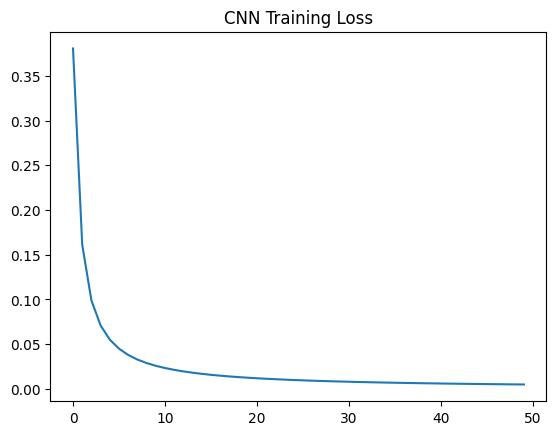

In [33]:
plt.plot(cnn_losses)
plt.title("CNN Training Loss")
plt.show()

## Analysis

Which model generalizes better?
CNN generalizes better because it captures spatial structure in images.


Does pooling improve test performance?
Yes. Pooling reduces overfitting and improves robustness to small shifts in image position.


Does dropout reduce validation-test gap?
Yes. Dropout reduces overfitting by preventing neurons from co-adapting.


How does parameter count relate to test accuracy?
Higher parameter counts increase model capacity but also increase risk of overfitting. CNN achieves good performance with fewer parameters due to parameter sharing.


Does CNN scale better with larger images?
Yes. CNN parameter count grows slowly with image size because filters are shared across the image.
Dense networks scale poorly since parameters increase with input dimension.


In [34]:
def initialize_adam(params):
    m = {}
    v = {}

    for key in params:
        m[key] = np.zeros_like(params[key])
        v[key] = np.zeros_like(params[key])

    return m,v

In [35]:
def adam_update(params,grads,m,v,t,lr=0.001,beta1=0.9,beta2=0.999,eps=1e-8):

    for key in params:
        m[key] = beta1*m[key] + (1-beta1)*grads[key]
        v[key] = beta2*v[key] + (1-beta2)*(grads[key]**2)
        m_hat = m[key] / (1-beta1**t)
        v_hat = v[key] / (1-beta2**t)
        params[key] -= lr * m_hat / (np.sqrt(v_hat)+eps)

    return params,m,v

In [36]:
def gradient_norm(grads):
    total = 0
    for g in grads.values():
        total += np.sum(g**2)
    return np.sqrt(total)

In [37]:
def train_cnn_optimizer(X,y,optimizer="sgd",epochs=50,lr=0.01):
    global filters,W_dense,b_dense
    losses=[]
    grad_norms=[]
    params={"W":W_dense,"b":b_dense}
    m,v = initialize_adam(params)
    t=1

    for epoch in range(epochs):
        epoch_loss=0
        for i in range(len(X)):
            img=X[i]
            label=y[i]
            y_hat,flat = cnn_forward(img,filters,W_dense,b_dense)
            loss=bce_loss(label,y_hat)
            dz=y_hat-label
            grads={}
            grads["W"]=flat.T@dz
            grads["b"]=dz
            grad_norms.append(gradient_norm(grads))

            if optimizer=="sgd":
                params["W"] -= lr*grads["W"]
                params["b"] -= lr*grads["b"]
            elif optimizer=="adam":
                params,m,v = adam_update(params,grads,m,v,t,lr)
            t+=1
            epoch_loss+=loss
        losses.append(epoch_loss/len(X))

    return losses,grad_norms

In [38]:
loss_sgd,grad_sgd = train_cnn_optimizer(
    X_train_img,
    y_train_img,
    optimizer="sgd",
    epochs=50
)

In [39]:
loss_adam,grad_adam = train_cnn_optimizer(
    X_train_img,
    y_train_img,
    optimizer="adam",
    epochs=50
)

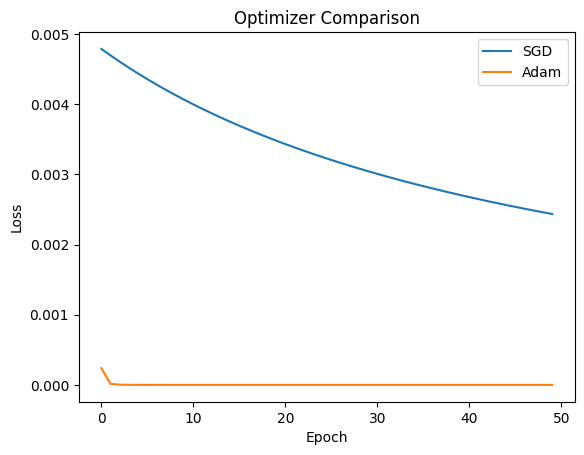

In [40]:
plt.plot(loss_sgd,label="SGD")
plt.plot(loss_adam,label="Adam")

plt.legend()
plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

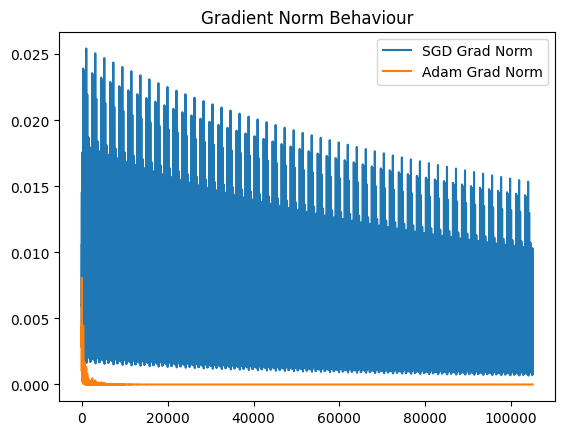

In [41]:
plt.plot(grad_sgd,label="SGD Grad Norm")
plt.plot(grad_adam,label="Adam Grad Norm")
plt.legend()
plt.title("Gradient Norm Behaviour")
plt.show()

In [42]:
correct=0

for i in range(len(X_test_img)):
    pred,_=cnn_forward(X_test_img[i],filters,W_dense,b_dense)
    if (pred>=0.5)==y_test_img[i]:
        correct+=1

print("CNN Test Accuracy:",correct/len(X_test_img))

CNN Test Accuracy: 1.0


## Final Reflection

Where did training fail due to structure?
Training failed in deeper networks using sigmoid activation due to the vanishing gradient problem. As gradients propagated through many layers, their magnitude decreased significantly, preventing effective learning in earlier layers.


Where did optimizer matter more than activation?
Optimizer choice mattered most in deeper networks where SGD struggled to converge efficiently. Momentum and Adam improved convergence by stabilizing gradient updates.


Where did activation matter more than depth?
Activation choice mattered when comparing sigmoid and ReLU networks with similar depth. ReLU networks trained faster and avoided vanishing gradient issues.


What causes gradient shrinkage?
Gradient shrinkage occurs when activation derivatives are small. During backpropagation, gradients are multiplied repeatedly by these derivatives, causing exponential decay across layers.


Why does CNN generalize better than dense networks?
CNNs exploit spatial locality through convolution filters and parameter sharing. This allows them to learn meaningful image features with significantly fewer parameters.


Why does dropout reduce overfitting?
Dropout randomly disables neurons during training. This prevents neurons from co-adapting and encourages the network to learn more robust and distributed representations.


When does depth hurt test performance?
Depth hurts test performance when the model becomes overly complex relative to the dataset size. This leads to overfitting and unstable gradient propagation.


Did validation always predict test performance correctly?
No. Validation performance generally indicates test performance but does not always predict it perfectly due to tuning bias, randomness in training, and dataset sampling differences.